In [18]:
import sys, os, pickle
import torch
sys.path.append('/home/om2382/mft-theory/')
from cluster import *
from core import *
from empirics import *
from functions import *
from LDR_dim import *
from ode_methods import *
from plotting import *
from theory import *
from utils import *
from functools import partial
import matplotlib.pyplot as plt

In [19]:
### --- SET UP ALL CONFIGS --- ###
from itertools import product
n_seeds = 10
macro_configs = config_generator(D0=[3, 4.15, 5.3])
micro_configs = tuple(product(macro_configs, list(range(n_seeds))))
prototype = False

### --- SELECT PARTICULAR CONFIG --- ###
try:
    i_job = int(os.environ['SLURM_ARRAY_TASK_ID']) - 1
except KeyError:
    i_job = 0
    prototype = True
params, i_seed = micro_configs[i_job]
i_config = i_job//n_seeds

new_random_seed_per_condition = True
if new_random_seed_per_condition:
    np.random.seed(i_job)
else: #Match random seeds across conditions
    np.random.seed(i_seed)

In [20]:
T = 200
N_bins = 4000
gamma = 0.99
D_bulk = 2
omega_star = 0.25
alpha = 1
R = 2
gamma = 0.99
i_min = np.argmin(np.abs(2*np.pi*np.fft.fftfreq(N_bins, T/N_bins) - omega_star))
omega_star = 2*np.pi*np.fft.fftfreq(N_bins, T/N_bins)[i_min]
cos_theta = 1.0 / np.sqrt(1.0 + omega_star**2)
res_spont = solve_spontaneous(N=N_bins, T=T,
                              alpha=alpha, R=R, D_bulk=D_bulk, gamma=gamma,
                              g=None,                      # if provided, g_eff := g; else g_eff := sqrt(alpha*R)*D
                              max_iters=500, tol=1e-9, mix=0.5)

D_crit_1 = 1/(gamma * cos_theta * res_spont['gain'])

### CHANGE THIS VALUE TO CHANGE REGIME FOR THEORY AND SIMULATION ###
D0 = params['D0']
D0 = 4.15 #chaotic task-selected
#D0 = 5.3 #nonchaotic task-selected


#Solve for theoretical autocovariance functions

res = solve_condensed(
    N=N_bins, T=T,
    alpha=alpha, R=2,
    D_bulk=D_bulk,   # ensure D_bulk < D0*cosθ*
    D0=D0,
    gamma=gamma, omega_star=omega_star,
    g=None, mix=0.5, iters=3000, tol=1e-9, plus=True
)
Cphi = Cphi_from_Cx_time(res['Cx_tau'])

In [21]:
### --- Set empirical parameters --- ###

#network properties size
N = 5000
phi_torch = lambda x: torch.erf((np.sqrt(np.pi)/2)*x)
phi_prime_torch = lambda x: torch.exp(-(np.pi/4)*x**2)
#lags window
T_window_emp = 1
dT_emp = 1
lags_emp = np.arange(0, T_window_emp, dT_emp)
n_lags_emp = int(T_window_emp/dT_emp)

#Set tasks
R = 2
gamma = 0.99
alpha = alpha
D_ = 2
N_tasks = int(alpha * N)
PR_D = 1
if PR_D < 1:
    beta_D = invert_PR_by_newton(PR_D)
    D = np.exp(-beta_D*np.arange(N_tasks)/N_tasks)
else:
    D = np.ones(N_tasks)
#g_correction = g / np.sqrt(np.sum(D**2)*R/N)
D = D * D_
g = np.sqrt(alpha * R * np.mean(D**2))
sigma_mn_all = np.zeros((R, R, N_tasks))
total_attempts = 0
for i_task in range(N_tasks):
    sigma_mn_all[:,:,i_task], n_attempts = generate_positive_definite_covariance_block_haar(R=R,
                                                                                            gamma=gamma,
                                                                                            report_attempts=True)
    total_attempts += n_attempts
print(total_attempts)

freq = omega_star
theta0 = np.arctan(freq)
#D0 = params['D0']
Cs = np.transpose(sigma_mn_all, axes=(2,0,1))
real_freq = gamma * np.cos(theta0)
i_mode = np.argmin(np.abs(np.amax(np.linalg.eigvals(Cs).real, 1) - real_freq))
D_changed = D.copy()
D_changed[i_mode] = D0

0


In [23]:
### Observe some activity
dt = 0.05

#sample W
W_, all_loadings = sample_W_optimized(sigma_mn_all, D_changed, N)

### --- Estimate C empirically --- ###

x, r = sample_activity(T_sim=200, dt_save=0.05, dt=0.05, W=W_, phi_torch=phi_torch,
                       runga_kutta=True, T_save_delay=0, noise_series=None)
Z = np.einsum('air, ti -> atr', all_loadings[i_mode:i_mode+1, :, 2:4], r) * D_changed[i_mode:i_mode+1,None,None]

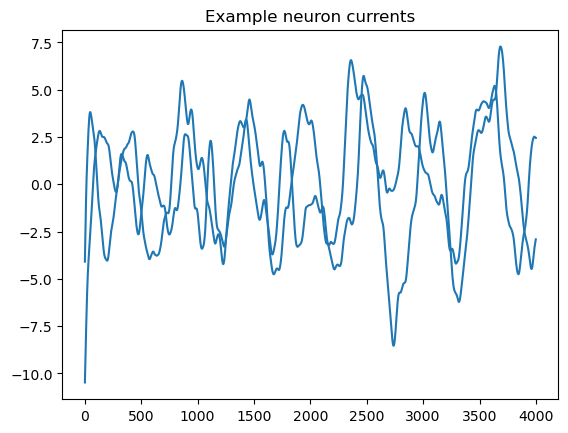

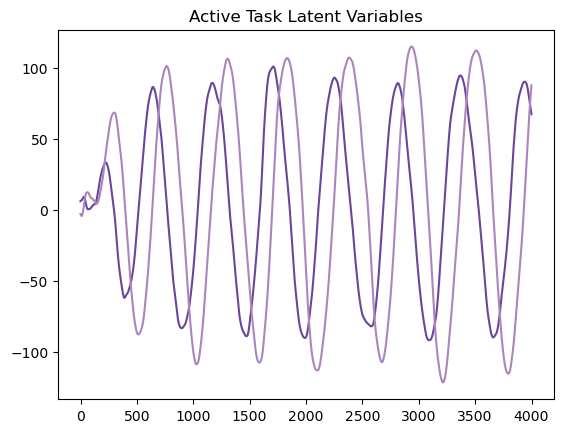

In [26]:
plt.figure()
plt.title('Example neuron currents')
plt.plot(x[:,0], 'C0')
plt.plot(x[:,1], 'C0')
plt.figure()
plt.title('Active Task Latent Variables')
plt.plot(Z[0,:,0], '#69469C')
plt.plot(Z[0,:,1], '#AB85BC')

In [ ]:
#estimate autocovariance statistics

#lags window
dt = 0.05
T_window_emp = 80
dT_emp = 0.5
lags_emp = np.arange(0, T_window_emp, dT_emp)
n_lags_emp = int(T_window_emp/dT_emp)
C_x_emp_avg = 0
C_phi_emp_avg = 0
N_W_samples = 1
for i_W_sample in range(N_W_samples):
    
    #fix sample
    W_, all_loadings = sample_W_optimized(sigma_mn_all, D_changed, N)
    
    ### --- Estimate C empirically --- ###

    x, r = sample_activity(T_sim=3000, dt_save=dT_emp, dt=0.05, W=W_, phi_torch=phi_torch,
                           runga_kutta=True, T_save_delay=100, noise_series=None)
    x = torch.from_numpy(x).type(torch.FloatTensor).to(0)
    r = torch.from_numpy(r).type(torch.FloatTensor).to(0)
    C_x_emp = compute_lagged_xcov(x[:,None,:], x[:,None,:], lags_emp, dt_save=dT_emp)
    C_phi_emp = compute_lagged_xcov(r[:,None,:], r[:,None,:], lags_emp, dt_save=dT_emp)
    C_x_emp_avg += C_x_emp / N_W_samples
    C_phi_emp_avg += C_phi_emp / N_W_samples

In [14]:
Cx_tau_emp = C_x_emp_avg.cpu().numpy().squeeze().mean(-1)
Cphi_tau_emp = C_phi_emp_avg.cpu().numpy().squeeze().mean(-1)

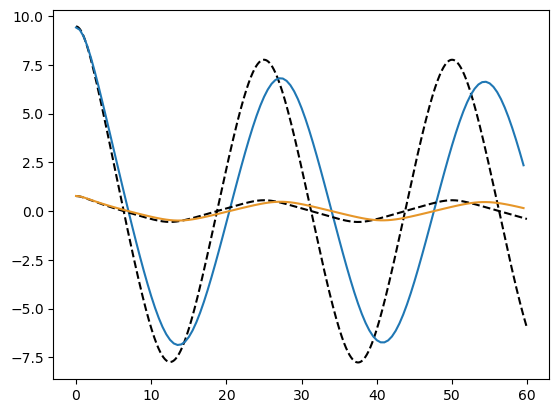

In [15]:
time_vec_theory = np.arange(0, 60, dt)
time_vec_emp = np.arange(0, 60, dT_emp)
plt.plot(time_vec_theory, res['Cx_tau'][:len(time_vec_theory)], 'k',linestyle='--')
plt.plot(time_vec_emp, Cx_tau_emp[:len(time_vec_emp)], 'C0')
plt.plot(time_vec_theory, Cphi[:len(time_vec_theory)], 'k', linestyle='--')
plt.plot(time_vec_emp, Cphi_tau_emp[:len(time_vec_emp)], '#E69629')